# Setup langgraph

In [ ]:
!pip install langchain_core langchain-anthropic langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 6.8 MB/s eta 0:00:00


In [ ]:
!pip install -U langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 1.2 MB/s eta 0:00:00


In [ ]:
import os
import getpass

#from langchain_anthropic import ChatAnthropic

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = ""

# LangGraph Email

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

# BUG FIX 1: 'gemini-3-flash-preview' does not exist.
# Use a valid model name such as 'gemini-2.0-flash' or 'gemini-1.5-flash'.
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=1.0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)

### States

In [ ]:
from pydantic import BaseModel, Field
from typing import Optional, List, Literal, Annotated

class MeetingData(BaseModel):
    participants: List[str] = Field(default_factory=list)
    date: Optional[str] = None
    time: Optional[str] = None
    missing_fields: List[str] = Field(default_factory=list)


class EmailData(BaseModel):
    draft: Optional[str] = None
    approval_status: Optional[
        Literal["pending", "approved", "edit"]
    ] = None
    followup_count: int = 0
    last_reply: Optional[str] = None
    reply_intent: Optional[
        Literal["confirmed", "negotiate", "declined"]
    ] = None
    status: Optional[Literal["sent", "failed"]] = None


# ===========Merge email==============
def merge_mail(current: EmailData, update: EmailData) -> EmailData:
    """Merge only explicitly set (non-None) fields from update into current.
    BUG FIX B: The original filter 'if v is not None' correctly keeps 0,
    but EmailData(followup_count=new_count) still sets all OTHER fields to
    their defaults (None/0), which then overwrite valid state values.
    Fix: only merge fields that differ from a fresh EmailData() default,
    OR the caller must pass only the changed fields via model_copy.
    Simplest robust fix: accept a dict directly and only merge provided keys.
    """
    if isinstance(update, dict):
        # Dict updates: only merge the keys explicitly provided
        current_dict = current.model_dump()
        current_dict.update(update)
        return EmailData(**current_dict)
    # EmailData object: merge only fields that are not None,
    # but treat followup_count specially — always take the max to avoid reset.
    current_dict = current.model_dump()
    update_dict = update.model_dump()
    merged = {**current_dict}
    for k, v in update_dict.items():
        if k == 'followup_count':
            # Always keep the higher count so increment is never lost
            merged[k] = max(current_dict[k], v)
        elif v is not None:
            merged[k] = v
    return EmailData(**merged)


class AgentState(BaseModel):
    messages: List[dict] = Field(default_factory=list)

    workflow: Optional[
        Literal["schedule", "ticket", "chat"]
    ] = None

    meeting: MeetingData = Field(default_factory=MeetingData)

    # BUG FIX 3: Added Field(default_factory=EmailData) so Pydantic has a default.
    email: Annotated[EmailData, merge_mail] = Field(default_factory=EmailData)

    response: Optional[str] = None

### nodes

####1. classify workflow
read: message

write: workflow

In [ ]:
from pydantic import BaseModel


class WorkflowOutput(BaseModel):
    workflow: Literal["schedule", "ticket", "chat"]


def classify_workflow(state: AgentState):
    user_input = state.messages[-1]["content"]

    structured_llm = llm.with_structured_output(WorkflowOutput)
    response = structured_llm.invoke(
        [
            {
                "role": "system",
                "content": (
                    "Classify the user's request into exactly one of the following labels:\n"
                    "- schedule (meeting scheduling)\n"
                    "- ticket (support or issue ticket)\n"
                    "- chat (general conversation)\n\n"
                    "If uncertain, choose the closest match.\n"
                    "Return only structured output."
                ),
            },
            {
                "role": "user",
                "content": user_input,
            },
        ]
    )
    print(f"workflow: {response.workflow}")
    return {"workflow": response.workflow}

####2. extract meeting info
Reads:

* messages

Writes:

* meeting.date

* meeting.time

* meeting.participants

In [ ]:
class MeetingExtraction(BaseModel):
    date: str | None = None
    time: str | None = None
    participants: list[str] | None = None


structured_extractor = llm.with_structured_output(MeetingExtraction)


def extract_meeting_info(state: AgentState):
    result = structured_extractor.invoke([
        {
            "role": "system",
            "content": (
                "Extract meeting information from the conversation.\n"
                "Return date (YYYY-MM-DD if possible), time (HH:MM), "
                "and participants (emails if possible)."
            ),
        },
        {
            "role": "user",
            "content": state.messages[-1]["content"],
        },
    ])

    # BUG FIX A: Merge extracted fields onto existing meeting state so previously
    # extracted values (date, time, participants) are never wiped by a partial update.
    # Returning a plain dict was replacing the whole MeetingData object.
    updated_meeting = MeetingData(
        date=result.date or state.meeting.date,
        time=result.time or state.meeting.time,
        participants=result.participants or state.meeting.participants,
        missing_fields=state.meeting.missing_fields,
    )

    print(f"meeting_update: date {updated_meeting.date}")
    print(f"meeting_update: time {updated_meeting.time}")
    print(f"meeting_update: participants {updated_meeting.participants}")

    return {"meeting": updated_meeting}

####3. check missing fields
read: meeting

write: meeting.missing_fields

In [ ]:
def check_missing_fields(state: AgentState):
    missing = []

    if not state.meeting.date:
        missing.append("date")

    if not state.meeting.time:
        missing.append("time")

    if not state.meeting.participants:
        missing.append("participants")

    print(f"meeting missing fields: {missing}")
    # BUG FIX A (part 2): Return a full MeetingData object so that date/time/participants
    # already stored in state are not wiped by a partial dict update.
    return {
        "meeting": MeetingData(
            date=state.meeting.date,
            time=state.meeting.time,
            participants=state.meeting.participants,
            missing_fields=missing,
        )
    }

#### 4. ask for missing info
read: meeting.missing_fields

write: response

In [ ]:
from langgraph.types import interrupt


def ask_for_missing_info(state: AgentState):
    missing = state.meeting.missing_fields

    question = (
        "I still need the following information: "
        + ", ".join(missing)
        + "."
    )
    print(f"response: {question}")

    # BUG FIX 5: Interrupt here so the user can actually provide the missing info
    # before looping back to extract_meeting_info. Without this, the graph
    # re-extracts from the same unchanged message and loops infinitely.
    user_reply = interrupt({"message": question})

    # Append the user's reply to messages so extract_meeting_info sees new input.
    updated_messages = state.messages + [user_reply]
    return {"messages": updated_messages, "response": question}

####5. draft email
read: meeting

write:
* email.draft
* response

In [ ]:
def draft_email(state: AgentState):
    meeting = state.meeting

    draft = (
        f"Subject: Meeting Request\n\n"
        f"Hi,\n\n"
        f"I would like to schedule a meeting on {meeting.date} "
        f"at {meeting.time}.\n\n"
        f"Best regards"
    )

    return {
        "email": EmailData(draft=draft),
        "response": draft,
    }

####6. handle approval (interrupt)
read: email.draft

write: email.approval_status

In [ ]:
def process_approval(state: AgentState):
    user_input = interrupt({
        "email_draft": state.email.draft,
        "message": "Approve or request edit?"
    })

    status = "pending"  # Default status if none matches
    if any(word in user_input["content"].lower() for word in ["approved", "ok", "looks good"]):
        status = "approved"
    elif "edit" in user_input["content"].lower():
        status = "edit"

    print(f"approval response from user: {user_input['content'].lower()}")
    print(f"Approval status determined: {status}")
    return {"email": EmailData(approval_status=status)}

####7. wait for reply
write: email.last_reply

in real system, this might pause graph

In [ ]:
def wait_for_reply(state: AgentState):
    # Placeholder: simulate no reply
    print("===PLACEHOLDER: NO REPLY RECIEVED===")
    return {"email": EmailData(last_reply=None)}

#### 8. Send follow up
read: email.followup_count

write:
* email.followup_count
* response

In [ ]:
def send_followup(state: AgentState):
    followup_text = """
    Hi again,

    Just following up regarding the meeting invitation.
    Please let me know if the proposed time works.

    Best,
    """
    new_count = state.email.followup_count + 1
    print(f"followup text: {followup_text}")
    print(f"followup count: {new_count}")

    return {
        "email": EmailData(
            followup_count=new_count,
            draft=followup_text
        )  # reducer merges this, won't wipe other fields
    }

####9. extract reply intent
read: email.last_reply

write: email.reply_intent

In [ ]:
class ReplyIntentOutput(BaseModel):
    reply_intent: Literal["confirmed", "negotiate", "declined"]


structured_reply_parser = llm.with_structured_output(ReplyIntentOutput)


def extract_reply_intent(state: AgentState):
    reply = state.email.last_reply

    if not reply:
        return {}

    result = structured_reply_parser.invoke([
        {
            "role": "system",
            "content": (
                "Classify the email reply intent as one of:\n"
                "- confirmed\n"
                "- negotiate\n"
                "- declined\n"
                "Return structured output only."
            ),
        },
        {"role": "user", "content": reply},
    ])
    print(f"reply intent: {result.reply_intent}")
    return {"email": EmailData(reply_intent=result.reply_intent)}

####10. book calendar
read: meeting

write: response

In [ ]:
def book_calendar(state: AgentState):
    meeting = state.meeting

    confirmation = (
        f"Meeting confirmed and booked on {meeting.date} "
        f"at {meeting.time}."
    )
    print(f"confirmation: {confirmation}")

    return {"response": confirmation}

####11. send email
read: email.draft
write: response

In [ ]:
def send_email(state: AgentState):
    # Integrate real email API here
    print(f"===PLACEHOLDER - email sent: {state.email.draft}===")
    # BUG FIX (minor): Since merge_mail reducer is in place, just pass the diff.
    return {
        "email": EmailData(status="sent"),
        "response": "Email sent successfully."
    }

####12. send notification

In [ ]:
def send_notification(state: AgentState):
    # Integrate real notification API here
    print("===PLACEHOLDER - NOTIFICATION SENT===")
    return {"response": "Notification sent successfully."}

### add nodes

In [ ]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(AgentState)

builder.add_node("classify", classify_workflow)
builder.add_node("extract_meeting_info", extract_meeting_info)
# BUG FIX 4: Re-add check_missing_fields node — routing logic depends on it.
builder.add_node("check_missing_fields", check_missing_fields)
builder.add_node("ask_for_missing_info", ask_for_missing_info)
builder.add_node("draft", draft_email)
builder.add_node("process_approval", process_approval)
builder.add_node("send_email", send_email)
builder.add_node("wait_reply", wait_for_reply)
builder.add_node("followup", send_followup)
builder.add_node("extract_intent", extract_reply_intent)
builder.add_node("book_calendar", book_calendar)
builder.add_node("send_notification", send_notification)

builder.set_entry_point("classify")

## Conditional Routing

### route after `classify`

In [ ]:
builder.add_edge(START, "classify")

In [ ]:
def route_workflow(state: AgentState):
    if state.workflow == "schedule":
        return "extract_meeting_info"
    elif state.workflow == "ticket":
        return END  # ticket node not yet implemented
    else:
        return END

builder.add_conditional_edges(
    "classify",
    route_workflow,
    {
        "extract_meeting_info": "extract_meeting_info",
        END: END
    })

### after `extract_meeting_info` → `check_missing_fields`

In [ ]:
# BUG FIX 4 (continued): Route through check_missing_fields first,
# then conditionally branch based on missing_fields being populated.
builder.add_edge("extract_meeting_info", "check_missing_fields")

def route_missing_fields(state: AgentState):
    if state.meeting.missing_fields:
        return "ask_for_missing_info"
    return "draft"

builder.add_conditional_edges(
    "check_missing_fields",
    route_missing_fields,
    {
        "ask_for_missing_info": "ask_for_missing_info",
        "draft": "draft"
    }
)

### after `ask_for_missing_info`
user replies (via interrupt) → extract again

In [ ]:
# Safe to loop back now because ask_for_missing_info interrupts
# and appends the user reply to messages before returning.
builder.add_edge("ask_for_missing_info", "extract_meeting_info")

### after `draft`

In [ ]:
builder.add_edge("draft", "process_approval")

def route_approval(state: AgentState):
    if state.email.approval_status == "approved":
        return "send_email"
    elif state.email.approval_status == "edit":
        return "draft"
    return END

builder.add_conditional_edges(
    "process_approval",
    route_approval,
    {
        "send_email": "send_email",
        "draft": "draft",
        END: END
    }
)

### after `send_email`

In [ ]:
builder.add_edge("send_email", "wait_reply")

### after `wait_reply`

last_reply exists? → extract_intent

no reply → followup or send_notification

In [ ]:
MAX_FOLLOWUP_COUNT = 2

def route_followup(state: AgentState):
    if state.email.last_reply:
        print("Replied, extracting intent...")
        return "extract_intent"

    if state.email.followup_count < MAX_FOLLOWUP_COUNT:
        print("No reply, sending followup...")
        return "followup"

    print("No reply, send notification!")
    return "send_notification"

builder.add_conditional_edges(
    "wait_reply",
    route_followup,
    {
        "extract_intent": "extract_intent",
        "followup": "followup",
        "send_notification": "send_notification"
    }
)
builder.add_edge("followup", "wait_reply")

#### after `extract_intent`

In [ ]:
def route_intent(state: AgentState):
    if state.email.reply_intent == "confirmed":
        return "book_calendar"
    elif state.email.reply_intent == "negotiate":
        return "draft"
    else:  # declined
        return "send_notification"

builder.add_conditional_edges(
    "extract_intent",
    route_intent,
    {
        "book_calendar": "book_calendar",
        "draft": "draft",
        "send_notification": "send_notification"
    }
)
builder.add_edge("book_calendar", "send_notification")
builder.add_edge("send_notification", END)

## compile

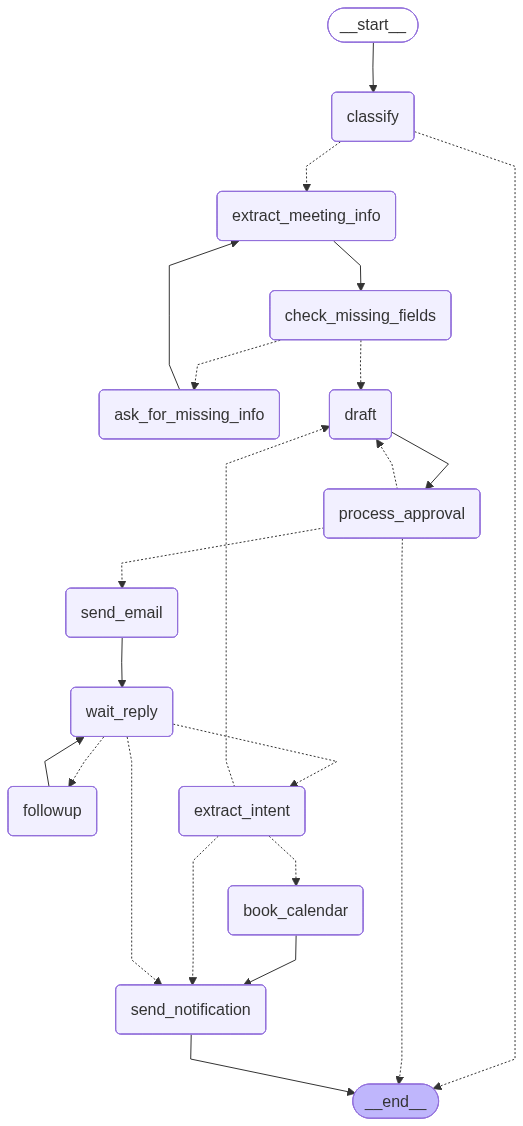

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

# run

In [ ]:
from langgraph.types import Command

initial_state = AgentState(
    messages=[
        {"role": "user",
         "content": "Schedule a meeting with Prof Linh next Monday at 12 am"}
    ],
    email=EmailData(
        followup_count=0,
        last_reply=None,
        approval_status=None,
        reply_intent=None
    )
)
config = {"configurable": {"thread_id": "test-1"},
          "recursion_limit": 25}

result = graph.invoke(initial_state, config=config)
print("First invocation result:", result)

# Handle missing info interrupt (ask_for_missing_info)
while "__interrupt__" in result:
    print("\n--- INTERRUPTED ---")
    interrupt_data = result["__interrupt__"][0].value
    print("Message:", interrupt_data.get("message", ""))

    if "email_draft" in interrupt_data:
        print("\nDraft Email:")
        print(interrupt_data["email_draft"])
        prompt = "Type: approved / edit / cancel: "
    else:
        prompt = "Your reply: "

    user_input_string = str(input(prompt))
    user_decision_message = {"role": "user", "content": user_input_string}

    result = graph.invoke(
        Command(resume=user_decision_message),
        config=config,
    )
    print("\nAfter Resume:")
    print(result)

workflow: schedule
meeting_update: date next Monday
meeting_update: time 00:00
meeting_update: participants ['Prof Linh']
meeting missing fields: []
First invocation result: {'messages': [{'role': 'user', 'content': 'Schedule a meeting with Prof Linh next Monday at 12 am'}], 'workflow': 'schedule', 'meeting': MeetingData(participants=['Prof Linh'], date='next Monday', time='00:00', missing_fields=[]), 'email': EmailData(draft='Subject: Meeting Request\n\nHi,\n\nI would like to schedule a meeting on next Monday at 00:00.\n\nBest regards', approval_status=None, followup_count=0, last_reply=None, reply_intent=None, status=None), 'response': 'Subject: Meeting Request\n\nHi,\n\nI would like to schedule a meeting on next Monday at 00:00.\n\nBest regards', '__interrupt__': [Interrupt(value={'email_draft': 'Subject: Meeting Request\n\nHi,\n\nI would like to schedule a meeting on next Monday at 00:00.\n\nBest regards', 'message': 'Approve or request edit?'}, id='2e3c920d3f8f53e233396a3311ce038f

approval response from user: approved
Approval status determined: approved
placeholder - email sent: Subject: Meeting Request

Hi,

I would like to schedule a meeting on next Monday at 00:00.

Best regards
placeholder: No reply received.
No reply, sending followup...
followup text: 
    Hi again,

    Just following up regarding the meeting invitation.
    Please let me know if the proposed time works.

    Best,
    
followup count: 1
placeholder: No reply received.
No reply, sending followup...
followup text: 
    Hi again,

    Just following up regarding the meeting invitation.
    Please let me know if the proposed time works.

    Best,
    
followup count: 2
placeholder: No reply received.
No reply, send notification!
placeholder - notification sent

After Resume:
{'messages': [{'role': 'user', 'content': 'Schedule a meeting with Prof Linh next Monday at 12 am'}], 'workflow': 'schedule', 'meeting': MeetingData(participants=['Prof Linh'], date='next Monday', time='00:00', missing